# Step 1 — Identify Forecast Reporting Points

Identifies all Google GRRR streamflow gauges whose catchment intersects the target state's flood-affected LGAs, plus the state's GloFAS reference station. These gauges are the candidate forecast reporting points used in subsequent steps.

**Outputs** saved to blob storage:
```
ds-aa-nga-flooding/processed/workflow/{state}_gauges.parquet
```
Columns: `gauge_id`, `source`, `latitude`, `longitude`, `river`, `quality_verified`

**Next step**: `02_floodscan_benchmark.ipynb` — calculate historical flooding time series from Floodscan.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import ocha_stratus as stratus
from dotenv import load_dotenv

from src.constants import PROJECT_PREFIX, STATE_CONFIG
from src.datasources import grrr
from src.datasources.glofas import GF_STATIONS

load_dotenv()

/Users/hannahker/Desktop/AA/ds-aa-nga-flooding/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
STATE = "Adamawa"  # "Adamawa" or "Benue"

cfg = STATE_CONFIG[STATE]
BLOB_OUT = f"{PROJECT_PREFIX}/processed/workflow/{STATE.lower()}_gauges.parquet"

FIGURES_DIR = Path(f"figures/{STATE.lower()}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Area of Interest

The target LGAs are those identified as flood-affected in the state's trigger configuration.

In [4]:
gdf_lga = stratus.codab.load_codab_from_blob("NGA", admin_level=2)
gdf_state = gdf_lga[gdf_lga[cfg["adm1_col"]] == cfg["adm1_val"]].copy()
gdf_target = gdf_lga[gdf_lga["ADM2_PCODE"].isin(cfg["lga_pcodes"])].copy()
gdf_nontarget = gdf_state[~gdf_state["ADM2_PCODE"].isin(cfg["lga_pcodes"])]

print(f"State: {STATE}")
print(f"Target LGAs ({len(gdf_target)}): {sorted(gdf_target['ADM2_EN'].tolist())}")

State: Adamawa
Target LGAs (7): ['Demsa', 'Fufore', 'Girei', 'Lamurde', 'Numan', 'Yola North', 'Yola South']


## Forecast Reporting Points

Google GRRR provides streamflow reanalysis and reforecast at gauge locations derived from the HydroBASINS network. All gauges — including those not quality-verified — are included at this stage. Low-correlation gauges are filtered in Step 3.

The GloFAS station for this state is included as a secondary reference signal and saved alongside the GRRR gauges.

In [5]:
gdf_gauges = grrr.get_gauges_by_area(gdf_target, include_non_quality_verified=True)
gdf_gauges["source"] = "grrr"

n_total = len(gdf_gauges)
n_verified = gdf_gauges["quality_verified"].sum()

print(f"GRRR gauges found: {n_total} ({n_verified} quality-verified, {n_total - n_verified} not verified)")
print()

gf_station = cfg["glofas_station"]
gf_coords = GF_STATIONS[gf_station]
print(f"GloFAS reference station: {gf_station} ({gf_coords['lat']}°N, {gf_coords['lon']}°E)")

GRRR gauges found: 42 (1 quality-verified, 41 not verified)

GloFAS reference station: wuroboki (9.383°N, 12.767°E)


In [6]:
gf_row = pd.DataFrame([{
    "gauge_id": gf_station,
    "source": "glofas",
    "latitude": gf_coords["lat"],
    "longitude": gf_coords["lon"],
    "river": None,
    "quality_verified": None,
}])

df_display = pd.concat(
    [gdf_gauges[["gauge_id", "source", "latitude", "longitude", "river", "quality_verified"]],
     gf_row],
    ignore_index=True,
)
df_display

,gauge_id,source,latitude,longitude,river,quality_verified
0,hybas_1120834480,grrr,9.593750,12.764583,,False
1,hybas_1120835110,grrr,9.577083,11.468750,,False
2,hybas_1120835720,grrr,9.564583,12.768750,,False
3,hybas_1120836240,grrr,9.552083,12.756250,,False
4,hybas_1120837500,grrr,9.518750,11.793750,Benue,False
5,hybas_1120837510,grrr,9.518750,11.814583,Benue,False
6,hybas_1120837740,grrr,9.514583,11.785417,Benue,False
7,hybas_1120837770,grrr,9.514583,12.243750,Benue,False
8,hybas_1120838030,grrr,9.510417,11.897917,Benue,False
9,hybas_1120838040,grrr,9.510417,13.060417,,False


## Map

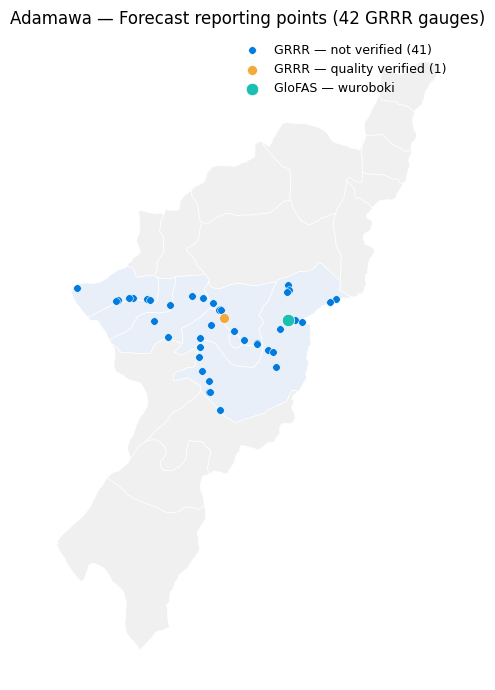

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))

gdf_nontarget.plot(ax=ax, color="#F0F0F0", edgecolor="white", linewidth=0.5)
gdf_target.plot(ax=ax, color="#E8EFF8", edgecolor="white", linewidth=0.5)

# GRRR gauges
verified = gdf_gauges[gdf_gauges["quality_verified"]]
unverified = gdf_gauges[~gdf_gauges["quality_verified"]]

ax.scatter(
    unverified.geometry.x, unverified.geometry.y,
    color="#007CE0", s=30, zorder=5, edgecolors="white", linewidths=0.4,
    label=f"GRRR — not verified ({len(unverified)})",
)
ax.scatter(
    verified.geometry.x, verified.geometry.y,
    color="#F4A93B", s=50, zorder=6, edgecolors="white", linewidths=0.4,
    label=f"GRRR — quality verified ({len(verified)})",
)

# GloFAS reference station
ax.scatter(
    gf_coords["lon"], gf_coords["lat"],
    color="#1EBFB3", s=80, zorder=7, edgecolors="white", linewidths=0.5,
    label=f"GloFAS — {gf_station}",
)

ax.legend(fontsize=9, frameon=False)
ax.set_axis_off()
ax.set_title(
    f"{STATE} — Forecast reporting points ({n_total} GRRR gauges)",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_reporting_points.png", dpi=150, bbox_inches="tight")
plt.show()

## Save

In [8]:
df_out = df_display.copy()
stratus.upload_parquet_to_blob(df_out, BLOB_OUT)
print(f"Saved {len(df_out)} gauges ({len(df_out) - 1} GRRR + 1 GloFAS) to {BLOB_OUT}")

Saved 43 gauges (42 GRRR + 1 GloFAS) to ds-aa-nga-flooding/processed/workflow/adamawa_gauges.parquet
